#Mounting Drive

In [1]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [2]:
from google.oauth2 import service_account
from googleapiclient.discovery import build
SCOPES = ["https://www.googleapis.com/auth/drive",
          "https://www.googleapis.com/auth/forms.body"]

#Connecting to Google API Key file
SERVICE_ACCOUNT_FILE = "/content/drive/My Drive/TADATASET/form-generator-project-ac479f21d09f.json"
creds = service_account.Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
drive_service = build('drive', 'v3', credentials=creds)
form_service = build('forms', 'v1', credentials=creds)

#Reading Document

In [3]:
from googleapiclient.discovery import build
from google.colab import auth
from oauth2client.client import GoogleCredentials
import os

# 1. Autentikasi Google
auth.authenticate_user()
creds = GoogleCredentials.get_application_default()
drive_service = build('drive', 'v3', credentials=creds)

# 2. Path
input_path  = "/content/drive/My Drive/TADATASET/KKNPenari/FORM_Result/"
output_path = "/content/drive/My Drive/TADATASET/KKNPenari/FORM_Result/xlsx/"
os.makedirs(output_path, exist_ok=True)

# 3. Cari FOLDER_ID otomatis dari path input
folder_name = "FORM_Result"
results = drive_service.files().list(
    q=f"name='{folder_name}' and mimeType='application/vnd.google-apps.folder'",
    fields="files(id, name)"
).execute()

folder_id = results['files'][0]['id']
print(f"✅ Folder ditemukan, ID: {folder_id}")

# 4. Ambil semua file Google Sheets di folder tersebut
sheets = drive_service.files().list(
    q=f"'{folder_id}' in parents and mimeType='application/vnd.google-apps.spreadsheet'",
    fields="files(id, name)"
).execute().get('files', [])

print(f"📄 Ditemukan {len(sheets)} file Google Sheets\n")

# 5. Export satu per satu ke .xlsx
for file in sheets:
    file_id   = file['id']
    file_name = file['name']

    try:
        content = drive_service.files().export_media(
            fileId=file_id,
            mimeType='application/vnd.openxmlformats-officedocument.spreadsheetml.sheet'
        ).execute()

        save_path = os.path.join(output_path, file_name + ".xlsx")
        with open(save_path, 'wb') as f:
            f.write(content)

        print(f"✅ {file_name}.xlsx")

    except Exception as e:
        print(f"❌ Gagal: {file_name} → {e}")

print("\n🎉 Semua file selesai diconvert!")

# 6. Verifikasi hasil
print("\n📂 File xlsx yang tersimpan:")
for f in os.listdir(output_path):
    if f.endswith('.xlsx'):
        print(f"   - {f}")

✅ Folder ditemukan, ID: 1GVDOZZxuuJBqk5eZh_6dnqlFVLNipoVy
📄 Ditemukan 8 file Google Sheets

✅ Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 701-793 (Jawaban).xlsx
✅ Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 601-700 (Jawaban).xlsx
✅ Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 501-600 (Jawaban).xlsx
✅ Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 301-400 (Jawaban).xlsx
✅ Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 401-500 (Jawaban).xlsx
✅ Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 201-300 (Jawaban).xlsx
✅ Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 101-200 (Jawaban).xlsx
✅ Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 001-100 (Jawaban).xlsx

🎉 Semua file selesai diconvert!

📂 File xlsx yang tersimpan:
   - KKNP-FORM RESULT-1101~1111.xlsx
   - KKNP-FORM RESULT-1001~1100.xlsx
   - KKNP-FORM RESULT-901~1000.xlsx
   - KKNP-FORM RESULT-801~900.xlsx
   - KKNP-FORM RESULT-701~800.xlsx
   - KKNP-FORM RESULT-601~700.xlsx
   - KKNP-FORM RESULT-5

In [4]:
import os

path = "/content/drive/My Drive/TADATASET/KKNPenari/FORM_Result/xlsx/"
for filename in os.listdir(path):
    print(repr(filename))  # pakai repr() biar ekstensinya keliatan jelas

'KKNP-FORM RESULT-1101~1111.xlsx'
'KKNP-FORM RESULT-1001~1100.xlsx'
'KKNP-FORM RESULT-901~1000.xlsx'
'KKNP-FORM RESULT-801~900.xlsx'
'KKNP-FORM RESULT-701~800.xlsx'
'KKNP-FORM RESULT-601~700.xlsx'
'KKNP-FORM RESULT-501~600.xlsx'
'KKNP-FORM RESULT-401~500.xlsx'
'KKNP-FORM RESULT-301~400.xlsx'
'KKNP-FORM RESULT-201~300.xlsx'
'KKNP-FORM RESULT-101~200.xlsx'
'KKNP-FORM RESULT-001~100.xlsx'
'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 701-793 (Jawaban).xlsx'
'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 601-700 (Jawaban).xlsx'
'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 501-600 (Jawaban).xlsx'
'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 301-400 (Jawaban).xlsx'
'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 401-500 (Jawaban).xlsx'
'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 201-300 (Jawaban).xlsx'
'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 101-200 (Jawaban).xlsx'
'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 001-100 (Jawaban).xlsx'


#Name Format

In [6]:
# Program Rename File yang Lebih Kuat dan Tahan Spasi/Karakter
import os

# --- 1. SETTING PATH ---
# Menggunakan PATH yang sudah terverifikasi di Cell 1.
FOLDER_PATH = "/content/drive/My Drive/TADATASET/KKNPenari/FORM_Result/xlsx/"
FILM_CODE = "KKNP"

# Pola nama yang TIDAK PERLU DIUBAH (Hanya bagian rentang ID yang kita ekstrak)
POLA_BARU_DEPAN = f"{FILM_CODE}-FORM RESULT-"
POLA_BARU_BELAKANG = ".xlsx"

# --- 2. FUNGSI RENAME OTOMATIS ---

print(f"Mencari file di: {FOLDER_PATH}\n")
files_renamed = 0

if not os.path.exists(FOLDER_PATH):
    print(f"ERROR: Jalur tidak ditemukan: {FOLDER_PATH}")
else:
    # Mengambil daftar file dari folder
    file_list = os.listdir(FOLDER_PATH)

    for filename in file_list:
        if filename.endswith(" (Jawaban).xlsx"):
            try:
                # 1. Temukan Indeks awal dari 'ID '
                start_index = filename.find(" ID ")
                if start_index != -1:
                    # 2. Ambil string dari 'ID ' sampai akhir
                    id_suffix = filename[start_index + 4:] # +4 untuk melewati " ID "

                    # 3. Hapus ' (Jawaban).xlsx' untuk mendapatkan '001-100'
                    id_part = id_suffix.replace(" (Jawaban).xlsx", "")

                    # 4. Ganti "-" dengan "~" sesuai pola Cell 2
                    id_range_new = id_part.replace("-", "~")

                    # 5. Buat nama file baru: "DRNT-FORM RESULT-1~100.xlsx"
                    new_filename = POLA_BARU_DEPAN + id_range_new + POLA_BARU_BELAKANG

                    old_filepath = os.path.join(FOLDER_PATH, filename)
                    new_filepath = os.path.join(FOLDER_PATH, new_filename)

                    # Ganti nama file
                    os.rename(old_filepath, new_filepath)

                    print(f"✅ Berhasil rename: '{filename}'\n   menjadi: '{new_filename}'")
                    files_renamed += 1
                else:
                    print(f"❌ Melewati file: '{filename}'. Pola ' ID ' tidak ditemukan.")

            except Exception as e:
                print(f"❌ Gagal memproses file '{filename}'. Error: {e}")

    print(f"\n--- Selesai ---")
    print(f"Total file yang berhasil di-rename: {files_renamed} dari {len(file_list)} item di folder.")

Mencari file di: /content/drive/My Drive/TADATASET/KKNPenari/FORM_Result/xlsx/

✅ Berhasil rename: 'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 701-793 (Jawaban).xlsx'
   menjadi: 'KKNP-FORM RESULT-701~793.xlsx'
✅ Berhasil rename: 'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 601-700 (Jawaban).xlsx'
   menjadi: 'KKNP-FORM RESULT-601~700.xlsx'
✅ Berhasil rename: 'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 501-600 (Jawaban).xlsx'
   menjadi: 'KKNP-FORM RESULT-501~600.xlsx'
✅ Berhasil rename: 'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 301-400 (Jawaban).xlsx'
   menjadi: 'KKNP-FORM RESULT-301~400.xlsx'
✅ Berhasil rename: 'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 401-500 (Jawaban).xlsx'
   menjadi: 'KKNP-FORM RESULT-401~500.xlsx'
✅ Berhasil rename: 'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 201-300 (Jawaban).xlsx'
   menjadi: 'KKNP-FORM RESULT-201~300.xlsx'
✅ Berhasil rename: 'Pengujian Label Dataset FILM : Sewu Dino (SWDN) ID 101-200 (Jawaba

#Extract FK Parameter


In [8]:
import os

folder = "/content/drive/My Drive/TADATASET/KKNPenari/FORM_Result/xlsx/"
print("Isi folder:")
for f in sorted(os.listdir(folder)):
    print(f" →", f)

Isi folder:
 → KKNP-FORM RESULT-001~100.xlsx
 → KKNP-FORM RESULT-1001~1100.xlsx
 → KKNP-FORM RESULT-101~200.xlsx
 → KKNP-FORM RESULT-1101~1111.xlsx
 → KKNP-FORM RESULT-201~300.xlsx
 → KKNP-FORM RESULT-301~400.xlsx
 → KKNP-FORM RESULT-401~500.xlsx
 → KKNP-FORM RESULT-501~600.xlsx
 → KKNP-FORM RESULT-601~700.xlsx
 → KKNP-FORM RESULT-701~793.xlsx
 → KKNP-FORM RESULT-701~800.xlsx
 → KKNP-FORM RESULT-801~900.xlsx
 → KKNP-FORM RESULT-901~1000.xlsx


In [ ]:
import pandas as pd
import os
import re

# --- WAJIB DIUBAH SETIAP KALI PINDAH RENTANG DATA ---
film_code = "SWDN"
startpoint = 701  # UBAH INI
endpoint = 793    # UBAH INI

start_str = str(startpoint).zfill(3)
end_str = str(endpoint).zfill(3)

# --- PATH INPUT & OUTPUT ---
response_file_path = f"/content/drive/My Drive/TADATASET/Sewudino/FORM_Result/xlsx/{film_code}-FORM RESULT-{start_str}~{end_str}.xlsx"
output_dir = "/content/drive/My Drive/TADATASET/Sewudino/FKParam/"
output_filename = os.path.join(output_dir, f"FORM_PARAMETER {film_code} {start_str}-{end_str}.xlsx")

os.makedirs(output_dir, exist_ok=True)

df = pd.read_excel(response_file_path, header=None)

file_name_list = df.iloc[0, 3:].tolist()

# --- AUTO-DETECT NAMA RATER DARI KOLOM 2 ---
seen = set()
rater_names = []
rater_row_indices = {}  # name -> index baris di DataFrame

for df_row_idx in range(1, len(df)):
    name = str(df.iloc[df_row_idx, 2]).strip()
    if name.lower() not in ("nan", "", "none") and name not in seen:
        seen.add(name)
        rater_names.append(name)
        rater_row_indices[name] = df_row_idx

print(f"Rater terdeteksi ({len(rater_names)}): {rater_names}")

if len(rater_names) < 3:
    raise ValueError(f"Minimal 3 rater diperlukan. Hanya ditemukan: {rater_names}")

# --- WAJIB DIUBAH HANYA SEKALI (Emosi Baru) ---
emotions = ["Marah", "Sedih", "Netral", "Bahagia", "Jijik", "Takut", "Tidak Jelas"]

rows = []
for file_index, file_name in enumerate(file_name_list):
    cleaned_file_name = re.sub(r"\[\d+\]\s*", "", file_name).split(" ")[0]
    rater_responses = []

    for name in rater_names[:3]:
        rater_row = rater_row_indices.get(name)
        column_index = file_index + 3
        if rater_row is not None and column_index < df.shape[1]:
            response = df.iloc[rater_row, column_index]
            rater_responses.append(response if pd.notna(response) else "Tidak Jelas")
        else:
            rater_responses.append("Tidak Jelas")

    while len(rater_responses) < 3:
        rater_responses.append("Tidak Jelas")

    prob_dict = {e: rater_responses.count(e) / 3 for e in emotions}
    count_dict = {e: rater_responses.count(e) for e in emotions}
    n2_dict = {e: count_dict[e]**2 for e in emotions}

    rows.append([
        cleaned_file_name,
        *rater_responses[:3],
        prob_dict["Marah"], prob_dict["Sedih"], prob_dict["Netral"], prob_dict["Bahagia"], prob_dict["Jijik"], prob_dict["Takut"], prob_dict["Tidak Jelas"],
        n2_dict["Marah"], n2_dict["Sedih"], n2_dict["Netral"], n2_dict["Bahagia"], n2_dict["Jijik"], n2_dict["Takut"], n2_dict["Tidak Jelas"]
    ])

rater_cols = [f"Resp {i + 1} ({rater_names[i]})" for i in range(3)]
output_df = pd.DataFrame(rows, columns=[
    "File ID", *rater_cols,
    "P(M)", "P(S)", "P(N)", "P(B)", "P(J)", "P(T)", "P(TJ)",
    "N^2(M)", "N^2(S)", "N^2(N)", "N^2(B)", "N^2(J)", "N^2(T)", "N^2(TJ)"
])

output_df.to_excel(output_filename, index=False)
print(f"File berhasil disimpan di:\n{output_filename}")

Rater terdeteksi (3): ['Naufal Maulana', 'Moh. Ilham Ramadan', 'Ulfah']
File berhasil disimpan di:
/content/drive/My Drive/TADATASET/Sewudino/FKParam/FORM_PARAMETER SWDN 701-793.xlsx


#Single Group Fleiss Kappa Analysis

In [ ]:
import pandas as pd
from IPython.display import display

film_code = "HSL"
startpoint = 101
endpoint = 200


def parameterfile():
    parameterfilepath = f"/content/drive/My Drive/Tugas Akhir LJ/FORM_Result/FK_Parameter/{film_code}_FK/FORM_PARAMETER {film_code} {startpoint}-{endpoint}.xlsx"
    return parameterfilepath

df = pd.read_excel(parameterfile())
df.index = range(1, len(df) + 1)
styled_df = df.style.set_properties(**{'text-align': 'left'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
display(styled_df)

avg_count = ["P(M)", "P(S)", "P(N)", "P(B)", "P(TJ)"]
n_sq_count = ["N^2(M)", "N^2(S)", "N^2(N)", "N^2(B)", "N^2(TJ)"]
rata_rata_tertentu = df[avg_count].mean()
rata_rata_kuadrat = rata_rata_tertentu ** 2
n_sq = df[n_sq_count].sum()
n_data = len(df)
nsq_sum = n_sq.sum()
Pe = (rata_rata_tertentu ** 2).sum()
Po = (((1/(n_data*3*(3-1)))*(n_sq.sum()-(n_data*3))))
FK = (Po-Pe)/(1-Pe)
print(f"Fleiss Kappa Parameters\n\nAverage Probability:\n{rata_rata_tertentu}", f"\n\nN Square of each category:\n{n_sq}", f"\nNumber of data {n_data}")
print(f"\nFleiss Kappa Analysis\nPe\t{Pe}", f"\nPo\t{Po}",f"\nK\t{FK}")

#Multiple Group Fleiss Kappa Analysis

In [9]:
import os
import glob
import re
import pandas as pd
from IPython.display import display

film_code = "KKNP"

folder_to_merge = f"/content/drive/My Drive/TADATASET/KKNPenari/FKParam/"
output_dir = f"/content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Merge/"
output_file = os.path.join(output_dir, f"{film_code}-FKPARAMETER.xlsx")

os.makedirs(output_dir, exist_ok=True)

excel_files = sorted(glob.glob(os.path.join(folder_to_merge, "*.xlsx")))

if not excel_files:
    print("No .xlsx files found in the folder.")
else:
    print(f"Found {len(excel_files)} files to merge.")

    data_frames = []
    for file in excel_files:
        df_temp = pd.read_excel(file)

        resp_cols = [c for c in df_temp.columns if c.startswith("Resp ")]

        # Sort berdasarkan angka di "Resp X (...)", bukan alfabetis
        resp_cols_sorted = sorted(resp_cols, key=lambda x: int(re.search(r'Resp (\d+)', x).group(1)))
        rename_map = {col: f"Resp {i+1}" for i, col in enumerate(resp_cols_sorted)}
        df_temp = df_temp.rename(columns=rename_map)

        data_frames.append(df_temp)

    merged_df = pd.concat(data_frames, ignore_index=True)

    if os.path.exists(output_file):
        os.remove(output_file)
        print(f"Old file deleted: {output_file}")

    merged_df.index = range(1, len(merged_df) + 1)
    merged_df.to_excel(output_file, index=False)
    print(f"Merged file saved as: {output_file}")
    display(merged_df)

# Fleiss Kappa Calculation
avg_count = ["P(M)", "P(S)", "P(N)", "P(B)", "P(J)", "P(T)"]
n_sq_count = ["N^2(M)", "N^2(S)", "N^2(N)", "N^2(B)", "N^2(J)", "N^2(T)"]

avg_probabilities = merged_df[avg_count].mean()
sum_squared_counts = merged_df[n_sq_count].sum()
num_data_points = len(merged_df)
total_sum_squared_counts = sum_squared_counts.sum()

Pe = (avg_probabilities ** 2).sum()
Po = (1 / (num_data_points * 3 * (3 - 1))) * (total_sum_squared_counts - (num_data_points * 3))
Fleiss_Kappa = (Po - Pe) / (1 - Pe)

print(f"Fleiss Kappa Parameters\n\nAverage Probability:\n{avg_probabilities}",
      f"\n\nN Square of each category:\n{sum_squared_counts}",
      f"\nNumber of data: {num_data_points}")
print(f"\nFleiss Kappa Analysis\nPe\t{Pe}", f"\nPo\t{Po}", f"\nK\t{Fleiss_Kappa}")

Found 12 files to merge.
Merged file saved as: /content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Merge/KKNP-FKPARAMETER.xlsx


,File ID,Resp 1,Resp 2,Resp 3,P(M),P(S),P(N),P(B),P(J),P(T),P(TJ),N^2(M),N^2(S),N^2(N),N^2(B),N^2(J),N^2(T),N^2(TJ)
1,01-KKNP-UT-0001.wav,Tidak Jelas,Netral,Tidak Jelas,0.000000,0.0,0.333333,0.0,0.0,0.000000,0.666667,0,0,1,0,0,0,4
2,01-KKNP-UT-0002.wav,Tidak Jelas,Netral,Tidak Jelas,0.000000,0.0,0.333333,0.0,0.0,0.000000,0.666667,0,0,1,0,0,0,4
3,01-KKNP-UT-0003.wav,Tidak Jelas,Marah,Tidak Jelas,0.333333,0.0,0.000000,0.0,0.0,0.000000,0.666667,1,0,0,0,0,0,4
4,01-KKNP-UT-0004.wav,Tidak Jelas,Marah,Tidak Jelas,0.333333,0.0,0.000000,0.0,0.0,0.000000,0.666667,1,0,0,0,0,0,4
5,01-KKNP-UT-0005.wav,Tidak Jelas,Takut,Tidak Jelas,0.000000,0.0,0.000000,0.0,0.0,0.333333,0.666667,0,0,0,0,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,01-KKNP-UT-0996.wav,Tidak Jelas,Takut,Tidak Jelas,0.000000,0.0,0.000000,0.0,0.0,0.333333,0.666667,0,0,0,0,0,1,4
1108,01-KKNP-UT-0997.wav,Tidak Jelas,Takut,Tidak Jelas,0.000000,0.0,0.000000,0.0,0.0,0.333333,0.666667,0,0,0,0,0,1,4
1109,01-KKNP-UT-0998.wav,Tidak Jelas,Takut,Tidak Jelas,0.000000,0.0,0.000000,0.0,0.0,0.333333,0.666667,0,0,0,0,0,1,4
1110,01-KKNP-UT-0999.wav,Netral,Netral,Netral,0.000000,0.0,1.000000,0.0,0.0,0.000000,0.000000,0,0,9,0,0,0,0


Fleiss Kappa Parameters

Average Probability:
P(M)    0.071107
P(S)    0.060306
P(N)    0.387039
P(B)    0.039904
P(J)    0.001500
P(T)    0.089109
dtype: float64 

N Square of each category:
N^2(M)     429
N^2(S)     359
N^2(N)    2880
N^2(B)     271
N^2(J)       5
N^2(T)     449
dtype: int64 
Number of data: 1111

Fleiss Kappa Analysis
Pe	0.16802697371447314 
Po	0.15901590159015902 
K	-0.010830966677544173


#Processing

In [10]:
import pandas as pd

mergedfile_path = f"/content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Merge/{film_code}-FKPARAMETER.xlsx"
df = pd.read_excel(mergedfile_path, header=0)

response_columns = [1, 2, 3]

# Hitung jumlah jawaban unik per baris
df["Unique Responses"] = df.iloc[:, response_columns].nunique(axis=1)

# Outlier 1: Ada rater yang memilih "Tidak Jelas" (P(TJ) > 0)
outliers_PTJ = df[df["P(TJ)"] > 0]

# Outlier 2: Ketiga rater memilih emosi berbeda
# Exclude yang sudah masuk outliers_PTJ agar tidak duplikat
outliers_Resp = df[
    (df["Unique Responses"] == 3) &
    (~df.index.isin(outliers_PTJ.index))
]

# Gabungkan semua outlier
all_outliers = pd.concat([outliers_PTJ, outliers_Resp]).drop_duplicates()

# Data bersih (non-outlier)
clean_df = df[~df.index.isin(all_outliers.index)]

# Reporting
print(f"Data asli       : {len(df)}")
print(f"Data outlier    : {len(all_outliers)} ({(len(all_outliers) / len(df)) * 100:.2f}%)")
print(f"Data bersih     : {len(clean_df)} ({(len(clean_df) / len(df)) * 100:.2f}%)\n")

print(f"--- Outlier: Ada rater memilih 'Tidak Jelas' ({len(outliers_PTJ)} data) ---")
for index, row in outliers_PTJ.iterrows():
    print(f"{row['File ID']} | Resp 1: {row.iloc[response_columns[0]]} | Resp 2: {row.iloc[response_columns[1]]} | Resp 3: {row.iloc[response_columns[2]]}")

print(f"\n--- Outlier: Ketiga rater berbeda ({len(outliers_Resp)} data) ---")
for index, row in outliers_Resp.iterrows():
    print(f"{row['File ID']} | Resp 1: {row.iloc[response_columns[0]]} | Resp 2: {row.iloc[response_columns[1]]} | Resp 3: {row.iloc[response_columns[2]]}")

Data asli       : 1111
Data outlier    : 720 (64.81%)
Data bersih     : 391 (35.19%)

--- Outlier: Ada rater memilih 'Tidak Jelas' (709 data) ---
01-KKNP-UT-0001.wav | Resp 1: Tidak Jelas | Resp 2: Netral | Resp 3: Tidak Jelas
01-KKNP-UT-0002.wav | Resp 1: Tidak Jelas | Resp 2: Netral | Resp 3: Tidak Jelas
01-KKNP-UT-0003.wav | Resp 1: Tidak Jelas | Resp 2: Marah | Resp 3: Tidak Jelas
01-KKNP-UT-0004.wav | Resp 1: Tidak Jelas | Resp 2: Marah | Resp 3: Tidak Jelas
01-KKNP-UT-0005.wav | Resp 1: Tidak Jelas | Resp 2: Takut | Resp 3: Tidak Jelas
01-KKNP-UT-0006.wav | Resp 1: Tidak Jelas | Resp 2: Takut | Resp 3: Tidak Jelas
01-KKNP-UT-0007.wav | Resp 1: Tidak Jelas | Resp 2: Netral | Resp 3: Tidak Jelas
01-KKNP-UT-0010.wav | Resp 1: Tidak Jelas | Resp 2: Netral | Resp 3: Tidak Jelas
01-KKNP-UT-0011.wav | Resp 1: Tidak Jelas | Resp 2: Takut | Resp 3: Tidak Jelas
01-KKNP-UT-0012.wav | Resp 1: Tidak Jelas | Resp 2: Takut | Resp 3: Tidak Jelas
01-KKNP-UT-0014.wav | Resp 1: Tidak Jelas | Resp 2

In [11]:
import pandas as pd

non_outliers = df[~df.index.isin(outliers_PTJ.index) & ~df.index.isin(outliers_Resp.index)]

df = non_outliers.drop(columns=["Unique Responses"], errors="ignore")
df_original = df.copy()
df.index = range(1, len(df) + 1)

# Tambah Hasil Label
def determine_label(row):
    probs = {
        "Marah": row["P(M)"], "Sedih": row["P(S)"], "Netral": row["P(N)"],
        "Bahagia": row["P(B)"], "Jijik": row["P(J)"], "Takut": row["P(T)"]
    }
    return max(probs, key=probs.get)

df["Hasil Label"] = df.apply(determine_label, axis=1)

display_cols = ["File ID", "Resp 1", "Resp 2", "Resp 3",
                "P(M)", "P(S)", "P(N)", "P(B)", "P(J)", "P(T)", "Hasil Label"]

# Tampilkan SEMUA baris tanpa terpotong
print(f"Total data bersih: {len(df)} baris\n")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(df[display_cols])

# Reset opsi display agar tidak mempengaruhi cell lain
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

avg_count = ["P(M)", "P(S)", "P(N)", "P(B)", "P(J)", "P(T)"]
n_sq_count = ["N^2(M)", "N^2(S)", "N^2(N)", "N^2(B)", "N^2(J)", "N^2(T)"]
rata_rata_tertentu = df[avg_count].mean()
n_sq = df[n_sq_count].sum()
n_data = len(df)

Pe = (rata_rata_tertentu ** 2).sum()
Po = (1 / (n_data * 3 * (3 - 1))) * (n_sq.sum() - (n_data * 3))
FK = (Po - Pe) / (1 - Pe)

print(f"Fleiss Kappa Parameters\n\nAverage Probability:\n{rata_rata_tertentu}",
      f"\n\nN Square of each category:\n{n_sq}",
      f"\nNumber of data: {n_data}")
print(f"\nFleiss Kappa Analysis\nPe\t{Pe}", f"\nPo\t{Po}", f"\nK\t{FK}")

Total data bersih: 391 baris



,File ID,Resp 1,Resp 2,Resp 3,P(M),P(S),P(N),P(B),P(J),P(T),Hasil Label
1,01-KKNP-UT-0008.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral
2,01-KKNP-UT-0009.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral
3,01-KKNP-UT-0013.wav,Netral,Marah,Marah,0.666667,0.000000,0.333333,0.000000,0.0,0.000000,Marah
4,01-KKNP-UT-0016.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral
5,01-KKNP-UT-0022.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral
6,01-KKNP-UT-0024.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral
7,01-KKNP-UT-0026.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral
8,01-KKNP-UT-0031.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral
9,01-KKNP-UT-0033.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral
10,01-KKNP-UT-0035.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,Netral


Fleiss Kappa Parameters

Average Probability:
P(M)    0.113384
P(S)    0.081841
P(N)    0.634271
P(B)    0.074169
P(J)    0.000000
P(T)    0.096334
dtype: float64 

N Square of each category:
N^2(M)     309
N^2(S)     230
N^2(N)    2060
N^2(B)     213
N^2(J)       0
N^2(T)     251
dtype: int64 
Number of data: 391

Fleiss Kappa Analysis
Pe	0.436635175216163 
Po	0.8056265984654731 
K	0.6549777462426627


In [13]:
import os

# Save the filtered DataFrame to an Excel file
output_excel_path = f"/content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Filtered/{film_code}-FKPARAMETER-F.xlsx"

# Buat direktori otomatis kalau belum ada
os.makedirs(os.path.dirname(output_excel_path), exist_ok=True)

df.to_excel(output_excel_path, index=False)
print(f"\nFiltered data saved to: {output_excel_path}")


Filtered data saved to: /content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Filtered/KKNP-FKPARAMETER-F.xlsx


Filtered data loaded successfully from: /content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Filtered/KKNP-FKPARAMETER-F.xlsx
Percentage Agreement per Emotion Category (based on Majority Label):


,Total Data Points,Resp 1_Agreements,Resp 2_Agreements,Resp 3_Agreements,Total Rater Agreements,Total Possible Agreements,Percentage Agreement (%)
Hasil Label (English),,,,,,,
Angry,46,31,36,46,113,138,81.884058
Fear,45,32,25,45,102,135,75.555556
Happy,31,24,23,31,78,93,83.870968
Neutral,242,233,231,228,692,726,95.316804
Sad,27,24,23,27,74,81,91.358025



Percentage Agreement per Rater within Each Emotion Category:


,Resp 1 (%),Resp 2 (%),Resp 3 (%)
Angry,67.391304,78.260870,100.000000
Sad,88.888889,85.185185,100.000000
Neutral,96.280992,95.454545,94.214876
Happy,77.419355,74.193548,100.000000
Fear,71.111111,55.555556,100.000000
Disgust,0.000000,0.000000,0.000000


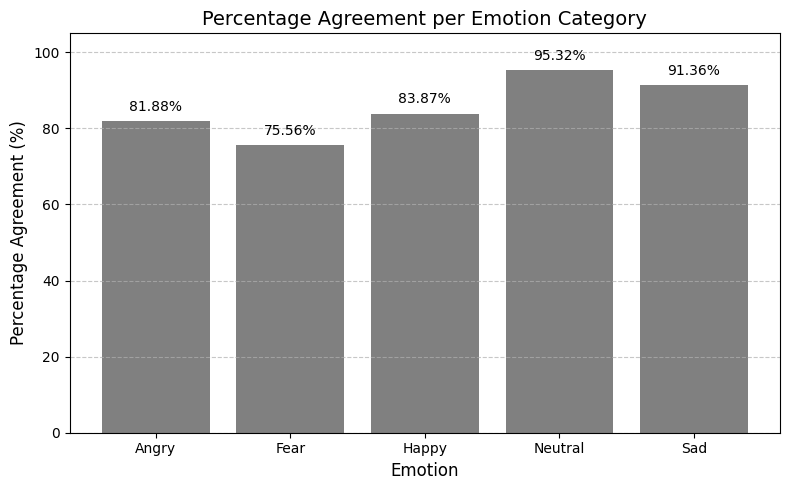

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

filtered_excel_path = f"/content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Filtered/{film_code}-FKPARAMETER-F.xlsx"

try:
    df_for_agreement = pd.read_excel(filtered_excel_path)
    print(f"Filtered data loaded successfully from: {filtered_excel_path}")
except FileNotFoundError:
    print(f"Error: The file '{filtered_excel_path}' was not found.")
    df_for_agreement = pd.DataFrame()
except Exception as e:
    print(f"An error occurred while loading the Excel file: {e}")
    df_for_agreement = pd.DataFrame()

emotions_id = ["Marah", "Sedih", "Netral", "Bahagia", "Takut", "Jijik"]
emotions_en = ["Angry", "Sad", "Neutral", "Happy", "Fear", "Disgust"]
emotion_map = dict(zip(emotions_id, emotions_en))

# --- AUTO-DETECT kolom Resp dari DataFrame ---
num_raters = 3
rater_columns = [f'Resp {i + 1}' for i in range(num_raters)]

# Ensure 'Hasil Label' is present
if 'Hasil Label' not in df_for_agreement.columns:
    print("Calculating 'Hasil Label' based on probability scores...")
    def determine_label(row):
        probs = {
            "Marah": row["P(M)"], "Sedih": row["P(S)"], "Netral": row["P(N)"],
            "Bahagia": row["P(B)"], "Takut": row["P(T)"],
            "Jijik": row["P(J)"], "Tidak Jelas": row["P(TJ)"]
        }
        return max(probs, key=probs.get)

    if not df_for_agreement.empty:
        df_for_agreement['Hasil Label'] = df_for_agreement.apply(determine_label, axis=1)
    else:
        print("Cannot calculate 'Hasil Label' as the DataFrame is empty.")

if not df_for_agreement.empty:
    df_for_agreement['Hasil Label (English)'] = df_for_agreement['Hasil Label'].map(emotion_map).fillna(df_for_agreement['Hasil Label'])

if not df_for_agreement.empty:
    for rater_col in rater_columns:
        if rater_col in df_for_agreement.columns:
            df_for_agreement[f'{rater_col}_Agrees_Majority'] = (df_for_agreement[rater_col] == df_for_agreement['Hasil Label'])
        else:
            print(f"Warning: Rater column '{rater_col}' not found in the DataFrame.")
            df_for_agreement[f'{rater_col}_Agrees_Majority'] = False

    agreement_stats = df_for_agreement[df_for_agreement['Hasil Label'] != 'Tidak Jelas'].groupby('Hasil Label (English)')
    total_data_points = agreement_stats.size().rename('Total Data Points')

    rater_agreement_sums = pd.DataFrame(index=total_data_points.index)
    for rater_col in rater_columns:
        if f'{rater_col}_Agrees_Majority' in df_for_agreement.columns:
            rater_agreement_sums[f'{rater_col}_Agreements'] = agreement_stats[f'{rater_col}_Agrees_Majority'].sum()
        else:
            rater_agreement_sums[f'{rater_col}_Agreements'] = 0

    agreement_stats = pd.concat([total_data_points, rater_agreement_sums], axis=1)
    agreement_stats['Total Rater Agreements'] = agreement_stats[[f'{col}_Agreements' for col in rater_columns]].sum(axis=1)
    agreement_stats['Total Possible Agreements'] = agreement_stats['Total Data Points'] * num_raters
    agreement_stats['Percentage Agreement (%)'] = (agreement_stats['Total Rater Agreements'] / agreement_stats['Total Possible Agreements']) * 100

    print("Percentage Agreement per Emotion Category (based on Majority Label):")
    display(agreement_stats)

    print("\nPercentage Agreement per Rater within Each Emotion Category:")
    rater_agreement_percentage = pd.DataFrame(index=emotions_en)
    for rater_col in rater_columns:
        if f'{rater_col}_Agrees_Majority' in df_for_agreement.columns:
            rater_agreement_percentage[f'{rater_col} (%)'] = (
                df_for_agreement.groupby('Hasil Label (English)')[f'{rater_col}_Agrees_Majority'].sum() /
                df_for_agreement.groupby('Hasil Label (English)')[f'{rater_col}_Agrees_Majority'].count()
            ) * 100
        else:
            rater_agreement_percentage[f'{rater_col} (%)'] = 0
    display(rater_agreement_percentage.fillna(0))

    # Plot
    emotions_for_plot = agreement_stats.index.tolist()
    percentage_agreement_for_plot = agreement_stats['Percentage Agreement (%)'].tolist()

    plt.figure(figsize=(8, 5))
    bars = plt.bar(emotions_for_plot, percentage_agreement_for_plot, color='gray')
    plt.title('Percentage Agreement per Emotion Category', fontsize=14)
    plt.xlabel('Emotion', fontsize=12)
    plt.ylabel('Percentage Agreement (%)', fontsize=12)
    plt.ylim(0, 105)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

else:
    print("Skipping agreement analysis and plotting as the DataFrame is empty.")

#Labelling

In [15]:
import pandas as pd

label_map = {
    "P(M)": "Marah",
    "P(S)": "Sedih",
    "P(N)": "Netral",
    "P(B)": "Bahagia",
    "P(T)": "Takut",
    "P(J)": "Jijik",
    "P(TJ)": "Tidak Jelas"
}

def label_dari_prob(row):
    labels = []
    for col, nama_label in label_map.items():
        if row[col] >= 0.5:
            labels.append(nama_label)
    return labels if labels else ["Tidak Ditentukan"]

# Terapkan ke DataFrame
df["Label Emosi (≥0.5)"] = df.apply(label_dari_prob, axis=1)

# Tampilkan hasil
print(df[["File ID", "Label Emosi (≥0.5)"]])

                 File ID Label Emosi (≥0.5)
1    01-KKNP-UT-0008.wav           [Netral]
2    01-KKNP-UT-0009.wav           [Netral]
3    01-KKNP-UT-0013.wav            [Marah]
4    01-KKNP-UT-0016.wav           [Netral]
5    01-KKNP-UT-0022.wav           [Netral]
..                   ...                ...
387  01-KKNP-UT-0981.wav           [Netral]
388  01-KKNP-UT-0993.wav          [Bahagia]
389  01-KKNP-UT-0995.wav            [Sedih]
390  01-KKNP-UT-0999.wav           [Netral]
391  01-KKNP-UT-1000.wav           [Netral]

[391 rows x 2 columns]


In [16]:
import pandas as pd
import shutil

output_path = f"/content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Filtered/{film_code}-FKPARAMETER-F.xlsx"

def determine_label(row):
    probs = {
        "Marah": row["P(M)"],
        "Sedih": row["P(S)"],
        "Netral": row["P(N)"],
        "Bahagia": row["P(B)"],  # ditambahkan
        "Jijik": row["P(J)"],
        "Takut": row["P(T)"]
    }
    return max(probs, key=probs.get)

df['Hasil Label'] = df.apply(determine_label, axis=1)

# Kolom generik tanpa nama rater
display_cols = ["File ID", "Resp 1", "Resp 2", "Resp 3",
                "P(M)", "P(S)", "P(N)", "P(B)", "P(J)", "P(T)", "Hasil Label"]

display(df[display_cols])

# Simpan ke Excel
df[display_cols].to_excel(output_path, index=False)
print(f"File disimpan di:\n{output_path}")

,File ID,Resp 1,Resp 2,Resp 3,P(M),P(S),P(N),P(B),P(J),P(T),Hasil Label
1,01-KKNP-UT-0008.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.0,0.0,0.000000,Netral
2,01-KKNP-UT-0009.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.0,0.0,0.000000,Netral
3,01-KKNP-UT-0013.wav,Netral,Marah,Marah,0.666667,0.000000,0.333333,0.0,0.0,0.000000,Marah
4,01-KKNP-UT-0016.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.0,0.0,0.000000,Netral
5,01-KKNP-UT-0022.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.0,0.0,0.000000,Netral
...,...,...,...,...,...,...,...,...,...,...,...
387,01-KKNP-UT-0981.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.0,0.0,0.000000,Netral
388,01-KKNP-UT-0993.wav,Bahagia,Bahagia,Bahagia,0.000000,0.000000,0.000000,1.0,0.0,0.000000,Bahagia
389,01-KKNP-UT-0995.wav,Sedih,Takut,Sedih,0.000000,0.666667,0.000000,0.0,0.0,0.333333,Sedih
390,01-KKNP-UT-0999.wav,Netral,Netral,Netral,0.000000,0.000000,1.000000,0.0,0.0,0.000000,Netral


File disimpan di:
/content/drive/My Drive/TADATASET/KKNPenari/FKParam/FK_Filtered/KKNP-FKPARAMETER-F.xlsx


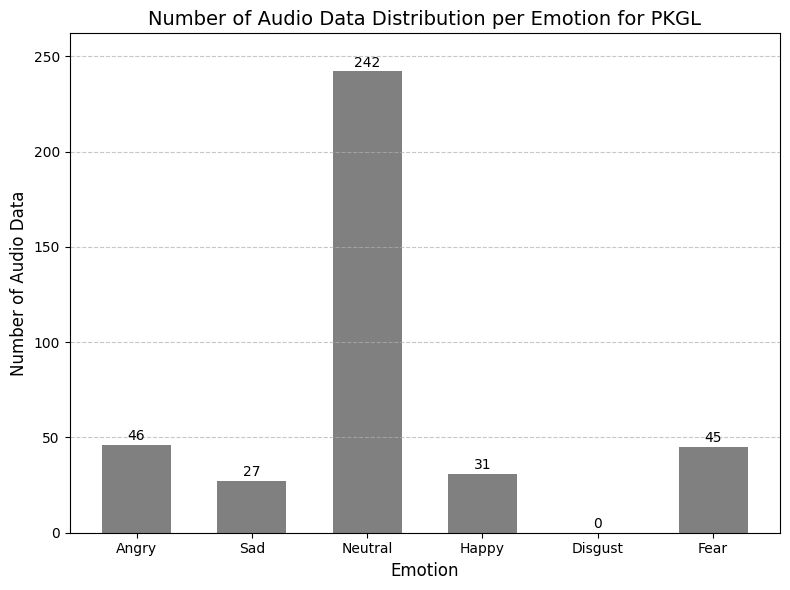

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung distribusi jumlah data audio per emosi
emotion_counts = df['Hasil Label'].value_counts()

# Tambah Bahagia & urutkan konsisten
emotions_id = ["Marah", "Sedih", "Netral", "Bahagia", "Jijik", "Takut"]
emotions_en = ["Angry", "Sad", "Neutral", "Happy", "Disgust", "Fear"]

# Reindex — emosi tanpa data akan diisi 0, bukan NaN
emotion_counts = emotion_counts.reindex(emotions_id, fill_value=0)

# Buat bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(emotions_en, emotion_counts.values, width=0.6, color="gray")
plt.title('Number of Audio Data Distribution per Emotion for PKGL', fontsize=14)  # Typo DNRT → DRNT
plt.ylim(0, max(emotion_counts.values) + 20)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Audio Data', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Label jumlah di atas bar
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval),
             ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

#Move Audio Data Base on their Label

**IF THE AUDIO ON SUB FOLDER**

In [19]:
import os
import shutil

# Path utama
base_path = '/content/drive/My Drive/TADATASET/KKNPenari/AudioData'

# Ekstensi audio yang ingin dipindahkan
audio_extensions = ('.mp3', '.wav', '.flac', '.ogg', '.m4a', '.aac')

# Loop semua file dalam subfolder
for root, dirs, files in os.walk(base_path):
    # Skip folder utama itu sendiri
    if root == base_path:
        continue

    for file in files:
        if file.lower().endswith(audio_extensions):
            src = os.path.join(root, file)
            dst = os.path.join(base_path, file)

            # Hindari overwrite jika nama file sama
            if os.path.exists(dst):
                name, ext = os.path.splitext(file)
                folder_name = os.path.basename(root)
                dst = os.path.join(base_path, f"{name}_{folder_name}{ext}")

            shutil.move(src, dst)
            print(f"Dipindahkan: {src} → {dst}")

print("\n✅ Selesai! Semua audio sudah dipindahkan ke folder utama.")


✅ Selesai! Semua audio sudah dipindahkan ke folder utama.


In [20]:
import os
from pathlib import Path
from collections import defaultdict

BASE_PATH = '/content/drive/My Drive/TADATASET/KKNPenari/AudioData'

def hitung_file(base_path):
    path = Path(base_path)

    if not path.exists():
        print(f"❌ Path tidak ditemukan: {base_path}")
        print("   Pastikan Google Drive sudah di-mount dan path benar.")
        return

    print("=" * 60)
    print(f"📁 ROOT: {base_path}")
    print("=" * 60)

    total_file   = 0
    total_folder = 0
    ekstensi_count = defaultdict(int)

    for folder, subfolders, files in os.walk(path):
        rel = os.path.relpath(folder, base_path)
        level = rel.count(os.sep)
        indent = "  " * level

        jumlah = len(files)
        if rel == ".":
            label = "📂 (root)"
        else:
            label = f"📂 {os.path.basename(folder)}"

        if jumlah > 0 or level == 0:
            print(f"{indent}{label}  →  {jumlah} file")

        total_file   += jumlah
        total_folder += 1 if rel != "." else 0

        for f in files:
            ext = Path(f).suffix.lower() or "(no ext)"
            ekstensi_count[ext] += 1

    print("=" * 60)
    print(f"📊 TOTAL FILE   : {total_file:,}")
    print(f"📊 TOTAL FOLDER : {total_folder:,}")
    print("-" * 40)
    print("🔍 Per ekstensi:")
    for ext, count in sorted(ekstensi_count.items(), key=lambda x: -x[1]):
        print(f"   {ext:<15} : {count:,}")
    print("=" * 60)

# ── Mount Google Drive jika belum ──
try:
    from google.colab import drive
    if not os.path.exists('/content/drive/My Drive'):
        print("🔗 Mounting Google Drive...")
        drive.mount('/content/drive')
    else:
        print("✅ Google Drive sudah ter-mount")
except ImportError:
    pass  # Bukan di Colab, lanjut saja

hitung_file(BASE_PATH)

✅ Google Drive sudah ter-mount
📁 ROOT: /content/drive/My Drive/TADATASET/KKNPenari/AudioData
📂 (root)  →  1111 file
📊 TOTAL FILE   : 1,111
📊 TOTAL FOLDER : 0
----------------------------------------
🔍 Per ekstensi:
   .wav            : 1,111


In [ ]:
import shutil
import os
import pandas as pd

# --- SESUAIKAN INI ---
film_code = "KKNP"
destination_folder = '/content/drive/My Drive/TADATASET/KKNPenari/DATA_Labeled'
audio_source_dir = '/content/drive/My Drive/TADATASET/KKNPenari/AudioData'

emotions = ["Marah", "Sedih", "Netral", "Bahagia", "Jijik", "Takut"]

# PERBAIKAN 1: Tambah P(B) untuk Bahagia
label_map = {
    "P(M)": "Marah",
    "P(S)": "Sedih",
    "P(N)": "Netral",
    "P(B)": "Bahagia",
    "P(J)": "Jijik",
    "P(T)": "Takut"
}

prob_thresholds = ["Prob_1", "Prob_0_5_to_1"]

# Buat struktur folder otomatis
print("Mempersiapkan struktur folder tujuan...")
for emotion in emotions:
    for threshold_name in prob_thresholds:
        # PERBAIKAN 2: Gunakan film_code dari variabel, bukan dari nama folder
        folder_path = os.path.join(destination_folder, emotion, film_code, threshold_name)
        os.makedirs(folder_path, exist_ok=True)
print("Struktur folder siap.\n")

# Fungsi labeling
def label_dari_prob(row):
    labels = []
    for col, nama_label in label_map.items():
        if col in row and pd.notna(row[col]) and row[col] >= 0.5:
            labels.append(nama_label)
    return labels if labels else ["Tidak Ditentukan"]

try:
    df["Label Emosi (≥0.5)"] = df.apply(label_dari_prob, axis=1)
    print("Labeling berdasarkan probabilitas 0.5 selesai.\n")
except NameError:
    print("ERROR: DataFrame 'df' tidak terdefinisi. Jalankan cell sebelumnya dulu.")
    raise

# Cari file audio
def cari_file(file_name, source_dir):
    # Cari langsung di root
    path_direct = os.path.join(source_dir, file_name)
    if os.path.exists(path_direct):
        return path_direct
    # Cari di subfolder
    for item in os.listdir(source_dir):
        subfolder = os.path.join(source_dir, item)
        if os.path.isdir(subfolder):
            path_sub = os.path.join(subfolder, file_name)
            if os.path.exists(path_sub):
                return path_sub
    return None

# Proses salin file
print("Memulai proses penyalinan file...")
copied = 0
not_found = 0
errors = 0

for index, row in df.iterrows():
    file_id = str(row['File ID']).split('.')[0]
    file_name = f"{file_id}.wav"
    assigned_labels = row["Label Emosi (≥0.5)"]

    source_path = cari_file(file_name, audio_source_dir)
    if not source_path:
        print(f"⚠️  File tidak ditemukan: {file_name}")
        not_found += 1
        continue

    for assigned_label in assigned_labels:
        if assigned_label not in emotions:
            continue

        prob_column = next((col for col, label in label_map.items() if label == assigned_label), None)
        if not prob_column or prob_column not in row:
            continue

        probability = row[prob_column]
        if pd.isna(probability):
            continue

        if probability == 1.0:
            subfolder = "Prob_1"
        elif probability >= 0.5:
            subfolder = "Prob_0_5_to_1"
        else:
            continue

        dest_path = os.path.join(destination_folder, assigned_label, film_code, subfolder, file_name)

        try:
            shutil.copy2(source_path, dest_path)
            copied += 1
        except Exception as e:
            print(f"❌ Error menyalin {file_name}: {e}")
            errors += 1

print(f"\nProses selesai.")
print(f"✅ Berhasil disalin : {copied} file")
print(f"⚠️  Tidak ditemukan  : {not_found} file")
print(f"❌ Error            : {errors} file")

Mempersiapkan struktur folder tujuan...
Struktur folder siap.

Labeling berdasarkan probabilitas 0.5 selesai.

Memulai proses penyalinan file...

Proses selesai.
✅ Berhasil disalin : 234 file
⚠️  Tidak ditemukan  : 0 file
❌ Error            : 0 file


#Visualisasi Data


DEBUGGING HASIL HITUNGAN AKHIR:
 - Marah: 46
 - Sedih: 27
 - Netral: 242
 - Bahagia: 31
 - Takut: 45
 - Jijik: 0
TOTAL JUMLAH DATA FISIK YANG DIHITUNG OLEH PROGRAM: 391


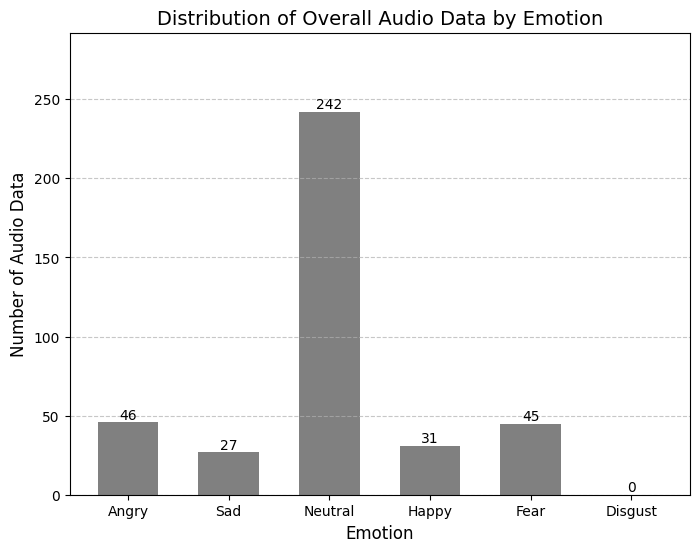

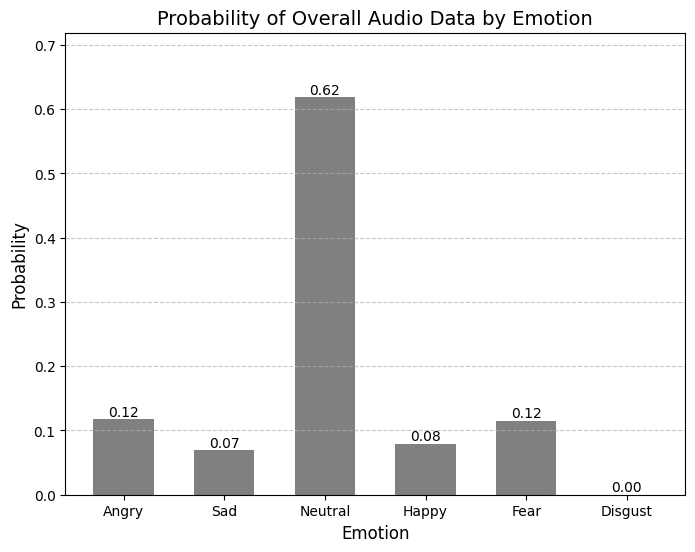

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the root directory where your labeled data is stored
labeled_data_root = '/content/drive/My Drive/TADATASET/KKNPenari/DATA_Labeled'

# === Konfigurasi emosi ===
emotions_id = ["Marah", "Sedih", "Netral", "Bahagia", "Takut", "Jijik"]
emotions_en = ["Angry", "Sad", "Neutral", "Happy", "Fear", "Disgust"]

# === Hitung jumlah data ===
emotion_counts = {}

for emotion_id in emotions_id:
    # Set untuk menyimpan nama file agar bisa kita debug
    all_files_for_emotion = []

    # Path ke folder emosi, e.g., /.../DATA_Labeled/Marah
    emotion_folder_path = os.path.join(labeled_data_root, emotion_id)

    if os.path.exists(emotion_folder_path):

        # Iterasi melalui DATA_DNRT
        for film_code_folder in os.listdir(emotion_folder_path):
            film_code_folder_path = os.path.join(emotion_folder_path, film_code_folder)

            if os.path.isdir(film_code_folder_path):

                # Iterasi melalui Prob_1 dan Prob_0_5
                for prob_subfolder in os.listdir(film_code_folder_path):
                    prob_subfolder_path = os.path.join(film_code_folder_path, prob_subfolder)

                    if os.path.isdir(prob_subfolder_path):
                        # Dapatkan semua file di subfolder probabilitas
                        files_in_folder = [
                            f for f in os.listdir(prob_subfolder_path)
                            if os.path.isfile(os.path.join(prob_subfolder_path, f))
                        ]

                        # Tambahkan daftar file ke list utama
                        all_files_for_emotion.extend(files_in_folder)

        # Hitungan total adalah panjang list (tidak menggunakan set())
        emotion_counts[emotion_id] = len(all_files_for_emotion)

    else:
        emotion_counts[emotion_id] = 0

# ... (Sisa kode untuk Plot 1 dan Plot 2 tetap sama) ...

# === Data jumlah dan probabilitas ===
counts = [emotion_counts[e_id] for e_id in emotions_id]
total = sum(counts)
probs = [ (c / total) if total > 0 else 0.0 for c in counts ]

# --- DEBUGGING: CETAK TOTAL AKHIR ---
print("\n========================================================")
print(f"DEBUGGING HASIL HITUNGAN AKHIR:")
for emotion, count in emotion_counts.items():
    print(f" - {emotion}: {count}")
print(f"TOTAL JUMLAH DATA FISIK YANG DIHITUNG OLEH PROGRAM: {total}")
print("========================================================")
# === Plot 1: Jumlah data ===
plt.figure(figsize=(8, 6))
bars = plt.bar(emotions_en, counts, width=0.6, color="gray")
plt.title('Distribution of Overall Audio Data by Emotion', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Audio Data', fontsize=12)
plt.ylim(0, max(counts) + 50 if total > 0 else 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Label jumlah di atas bar
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom', fontsize=10, color='black')

plt.show()

# === Plot 2: Probabilitas (0–1) ===
plt.figure(figsize=(8, 6))
bars2 = plt.bar(emotions_en, probs, width=0.6, color="gray")
plt.title('Probability of Overall Audio Data by Emotion', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.ylim(0, max(probs) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Label probabilitas di atas bar
for bar, p in zip(bars2.patches, probs):
    plt.text(bar.get_x() + bar.get_width()/2, p, f"{p:.2f}",
             ha='center', va='bottom', fontsize=10, color='black')

plt.show()

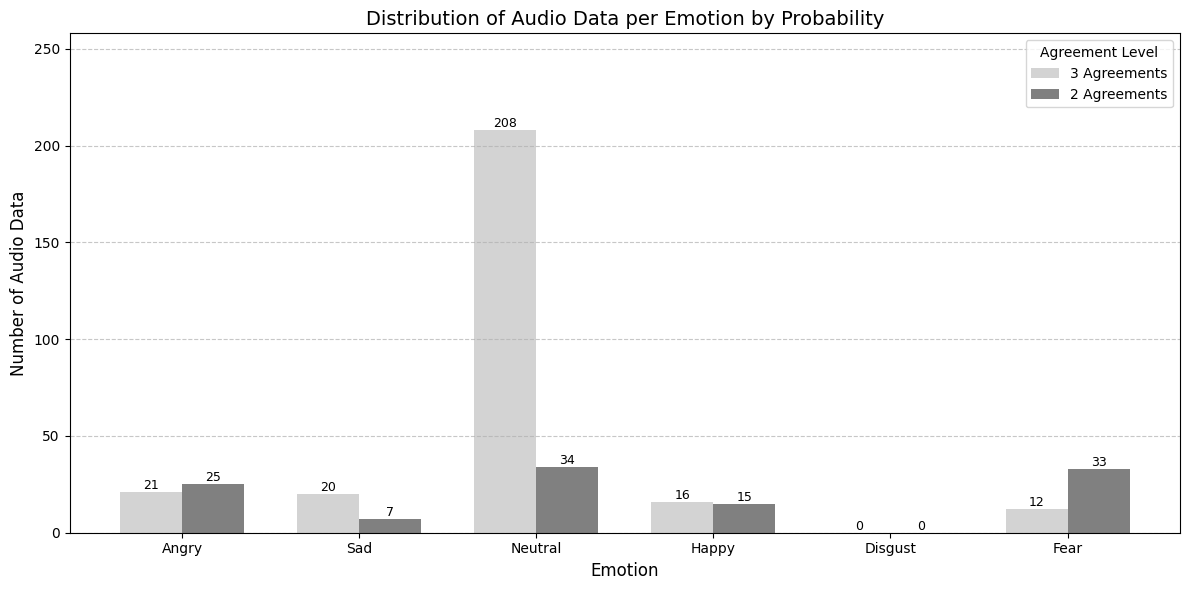

In [22]:
import matplotlib.pyplot as plt
import os

labeled_data_root = '/content/drive/My Drive/TADATASET/KKNPenari/DATA_Labeled'

# Tambah Bahagia/Happy
emotions_id = ["Marah", "Sedih", "Netral", "Bahagia", "Jijik", "Takut"]
emotions_en = ["Angry", "Sad", "Neutral", "Happy", "Disgust", "Fear"]

prob_thresholds = {
    "Prob_1": 1.0,
    "Prob_0_5_to_1": 0.5
}

emotion_prob_counts = {emotion_id: {name: 0 for name in prob_thresholds} for emotion_id in emotions_id}

for emotion_id in emotions_id:
    emotion_folder_path = os.path.join(labeled_data_root, emotion_id)
    if os.path.exists(emotion_folder_path):
        for film_code_folder in os.listdir(emotion_folder_path):
            film_code_folder_path = os.path.join(emotion_folder_path, film_code_folder)
            if os.path.isdir(film_code_folder_path):
                for prob_subfolder in os.listdir(film_code_folder_path):
                    prob_subfolder_path = os.path.join(film_code_folder_path, prob_subfolder)
                    if os.path.isdir(prob_subfolder_path) and prob_subfolder in prob_thresholds:
                        files_in_folder = [f for f in os.listdir(prob_subfolder_path) if os.path.isfile(os.path.join(prob_subfolder_path, f))]
                        emotion_prob_counts[emotion_id][prob_subfolder] += len(files_in_folder)

bar_width = 0.35
r1 = range(len(emotions_id))
r2 = [x + bar_width for x in r1]

prob_1_counts = [emotion_prob_counts[e]["Prob_1"] for e in emotions_id]
prob_0_5_counts = [emotion_prob_counts[e]["Prob_0_5_to_1"] for e in emotions_id]

plt.figure(figsize=(12, 6))
bars1 = plt.bar(r1, prob_1_counts, color='lightgrey', width=bar_width, label='3 Agreements')
bars2 = plt.bar(r2, prob_0_5_counts, color='grey', width=bar_width, label='2 Agreements')

plt.title('Distribution of Audio Data per Emotion by Probability', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Audio Data', fontsize=12)
plt.xticks([r + bar_width/2 for r in range(len(emotions_id))], emotions_en)
plt.ylim(0, max(max(prob_1_counts), max(prob_0_5_counts)) + 50)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Agreement Level')

def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=9, color='black')

add_labels(bars1)
add_labels(bars2)
plt.tight_layout()
plt.show()

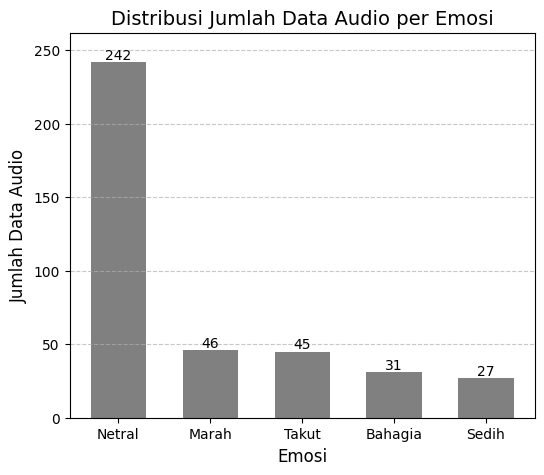

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung distribusi jumlah data audio per emosi dari DataFrame yang sudah dilabeli
emotion_counts = df['Hasil Label'].value_counts()

# Buat bar chart
plt.figure(figsize=(6, 5))
bars = plt.bar(emotion_counts.index, emotion_counts.values, width = 0.6, color="gray")
plt.title('Distribusi Jumlah Data Audio per Emosi', fontsize=14)
plt.ylim(0, max(emotion_counts.values) + 20)
plt.xlabel('Emosi', fontsize=12)
plt.ylabel('Jumlah Data Audio', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label jumlah di atas bar
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=10, color='black')

plt.show()

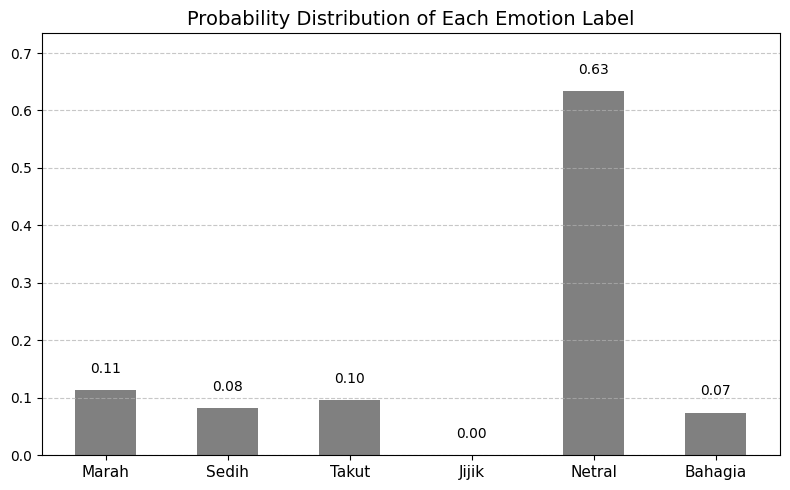

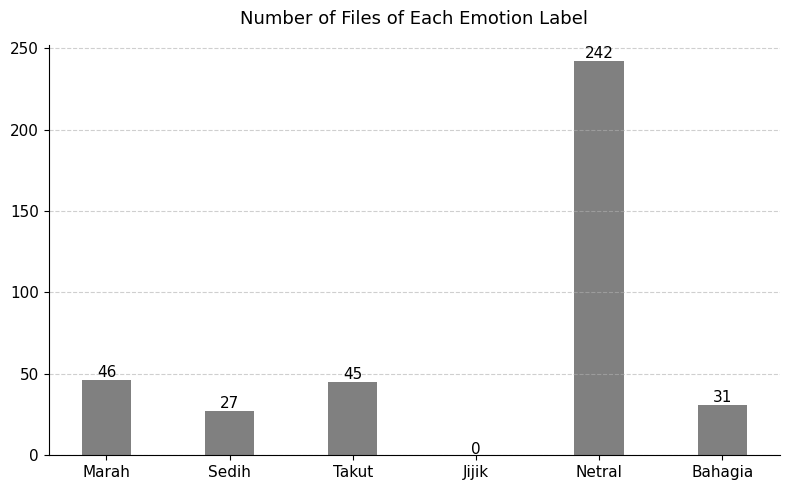

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Tambah P(B) Bahagia
rata2_prob = df[["P(M)", "P(S)", "P(T)", "P(J)", "P(N)", "P(B)"]].mean()
rata2_prob.index = ["Marah", "Sedih", "Takut", "Jijik", "Netral", "Bahagia"]

x = np.arange(len(rata2_prob))
width = 0.5

plt.figure(figsize=(8, 5))
bars = plt.bar(x, rata2_prob.values, width=width, color="gray")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.03, f"{yval:.2f}", ha='center', fontsize=10)

plt.xticks(x, rata2_prob.index, fontsize=11)
plt.yticks(fontsize=10)
plt.title("Probability Distribution of Each Emotion Label", fontsize=14)
plt.ylim(0, max(rata2_prob.values) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Tambah Bahagia
label_counts = {
    "Marah": len(df[df["P(M)"] >= 0.5]),
    "Sedih": len(df[df["P(S)"] >= 0.5]),
    "Takut": len(df[df["P(T)"] >= 0.5]),
    "Jijik": len(df[df["P(J)"] >= 0.5]),
    "Netral": len(df[df["P(N)"] >= 0.5]),
    "Bahagia": len(df[df["P(B)"] >= 0.5]),
}

x = np.arange(len(label_counts))
y = list(label_counts.values())
width = 0.4

plt.figure(figsize=(8, 5))
bars = plt.bar(x, y, width=width, color="gray")

for bar in bars:
    yval = bar.get_height()
    offset = 1 if yval < 20 else 2
    plt.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{int(yval)}", ha='center', fontsize=11)

plt.xticks(x, label_counts.keys(), fontsize=11)
plt.yticks(fontsize=11)
plt.title("Number of Files of Each Emotion Label", fontsize=13, pad=15)
plt.ylim(0, max(y) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

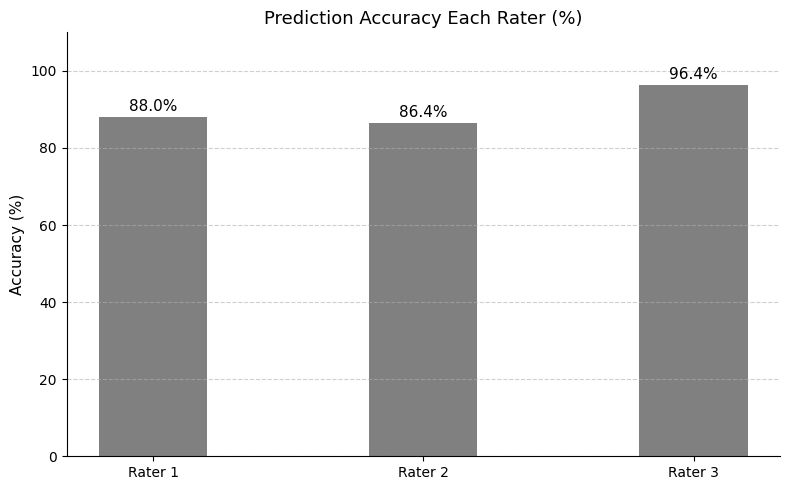

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

response_indices = [1, 2, 3]

# Tambah P(B) Bahagia dan P(N) Netral yang sebelumnya juga tidak ada
prob_indices = {
    "P(M)": 4,
    "P(S)": 5,
    "P(N)": 6,
    "P(B)": 7,
    "P(J)": 8,
    "P(T)": 9,
    "P(TJ)": 10
}

# Hitung label akhir untuk setiap baris
df["Label_Akhir"] = df.apply(determine_label, axis=1)

# Hitung akurasi
total_data = len(df)
akurasi = {}
for idx, r in enumerate(response_indices):
    rater_name = f"Rater {idx + 1}"
    cocok = (df.iloc[:, r] == df["Label_Akhir"]).sum()
    akurasi[rater_name] = (cocok / total_data) * 100

# Visualisasi
x = list(akurasi.keys())
y = list(akurasi.values())
width = 0.4

plt.figure(figsize=(8, 5))
bars = plt.bar(x, y, width=width, color="gray")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", ha='center', fontsize=11)

plt.ylim(0, 110)
plt.title("Prediction Accuracy Each Rater (%)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()